# **Import Libraries**
___

In [4]:
import numpy as np
import pandas as pd
import os

# **Load and Clean Data**
_____

In [5]:
os.chdir('/Users/dannyhogan/Desktop/ST-498')
df = pd.read_csv("Data/MacroVariables.csv",index_col=0)
recent_full_obs = df[df.isna().any(axis=1)]
max_date = recent_full_obs.index.min()
df = df[df.index < max_date]

# **Exploratory Data Analysis**
______

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


### **Correlation Matrix**

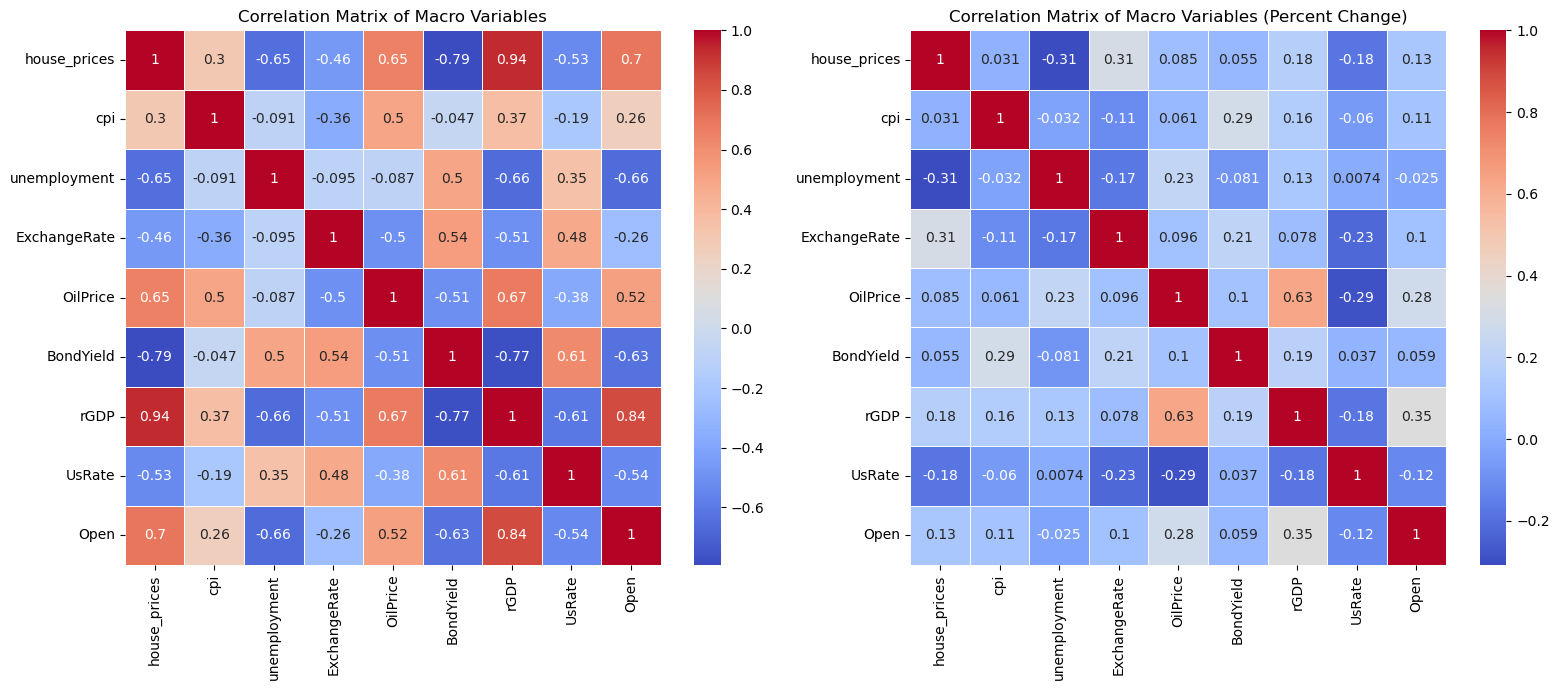

In [36]:
correlation_matrix = df.corr()
percent_df = df.pct_change().dropna()
per_corr_matrix = percent_df.corr()



fig, ax = plt.subplots(1,2,figsize=(16, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5,ax=ax[0])
ax[0].set_title('Correlation Matrix of Macro Variables')
sns.heatmap(per_corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5,ax=ax[1])
ax[1].set_title('Correlation Matrix of Macro Variables (Percent Change)')
plt.tight_layout()
plt.show()  



/var/folders/ts/x847bxb170n3msnnpmdpjll00000gn/T/ipykernel_44964/4095928693.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


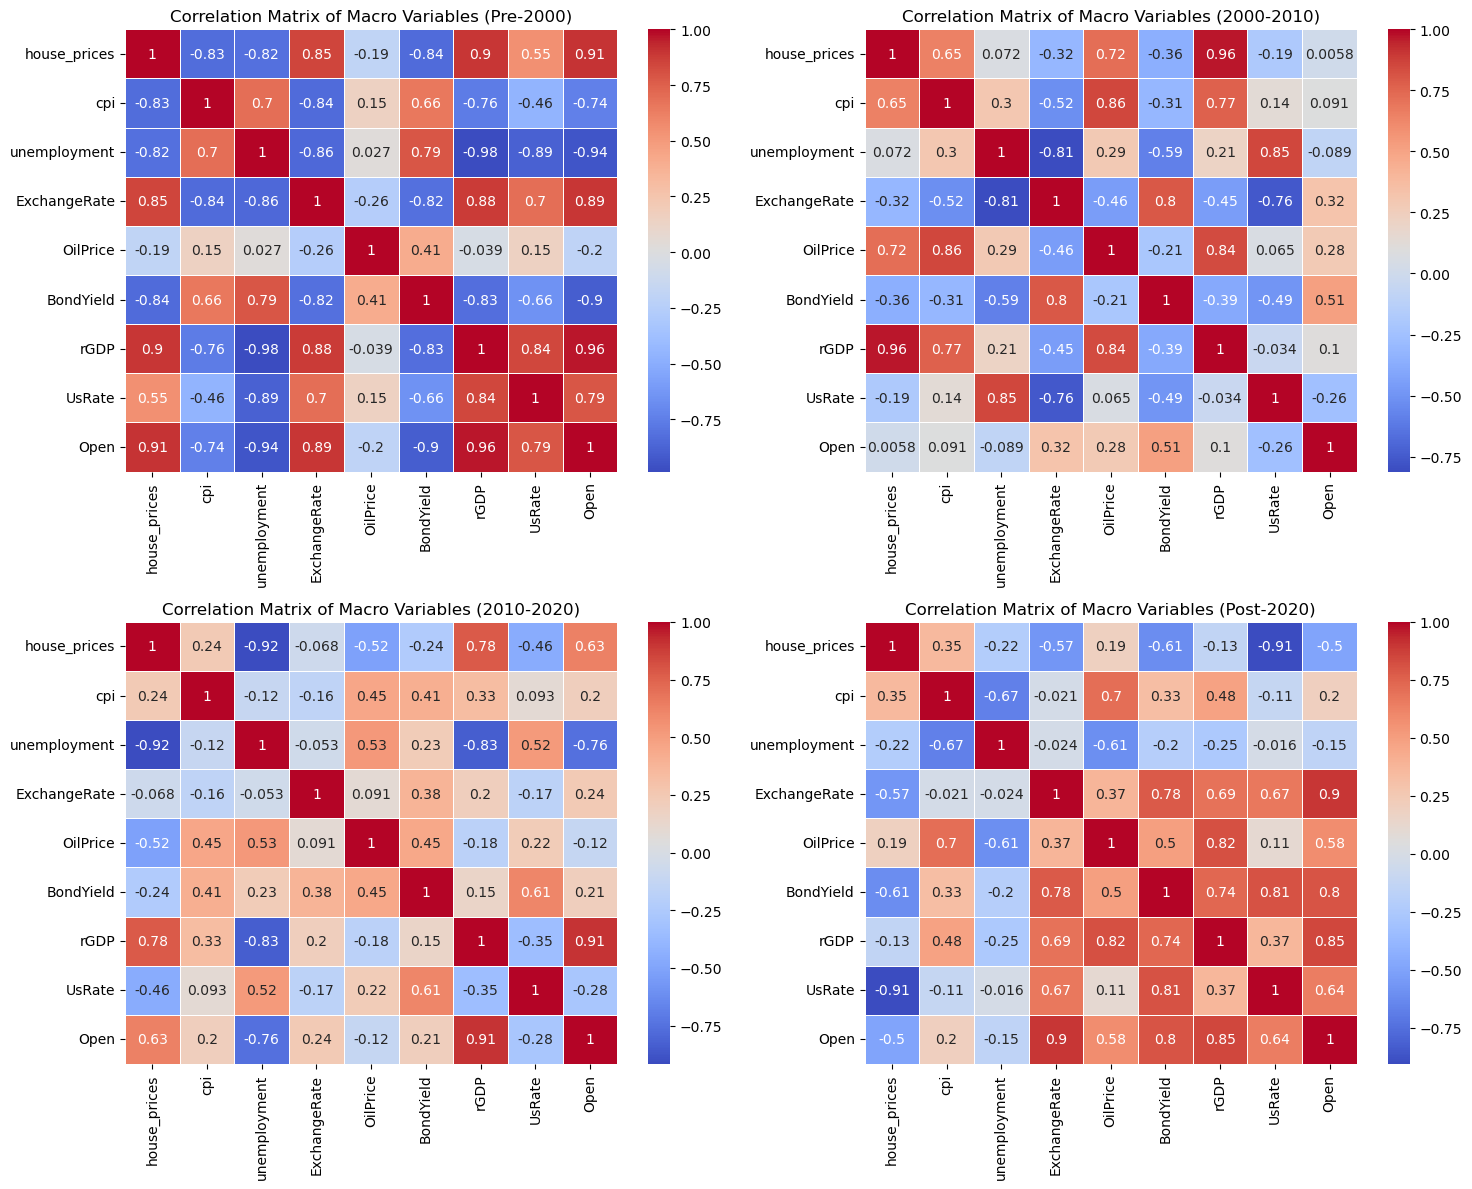

In [ ]:
df_pre = df[df.index < '1999-12-01']
df_early = df[(df.index > '1999-12-01') & (df.index < '2009-12-01')]
df_late = df[df.index > '2009-12-01']
df_covid = df[df.index > '2019-12-01']

fig, ax = plt.subplots(2, 2, figsize=(15, 12))
sns.heatmap(df_pre.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[0, 0])
ax[0, 0].set_title('Correlation Matrix of Macro Variables (Pre-2000)')
sns.heatmap(df_early.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax = ax[0, 1])
ax[0, 1].set_title('Correlation Matrix of Macro Variables (2000-2010)')
sns.heatmap(df_late.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[1, 0])
ax[1, 0].set_title('Correlation Matrix of Macro Variables (2010-2020)')
sns.heatmap(df_covid.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[1, 1])
ax[1, 1].set_title('Correlation Matrix of Macro Variables (Post-2020)')
plt.tight_layout()
plt.show()  

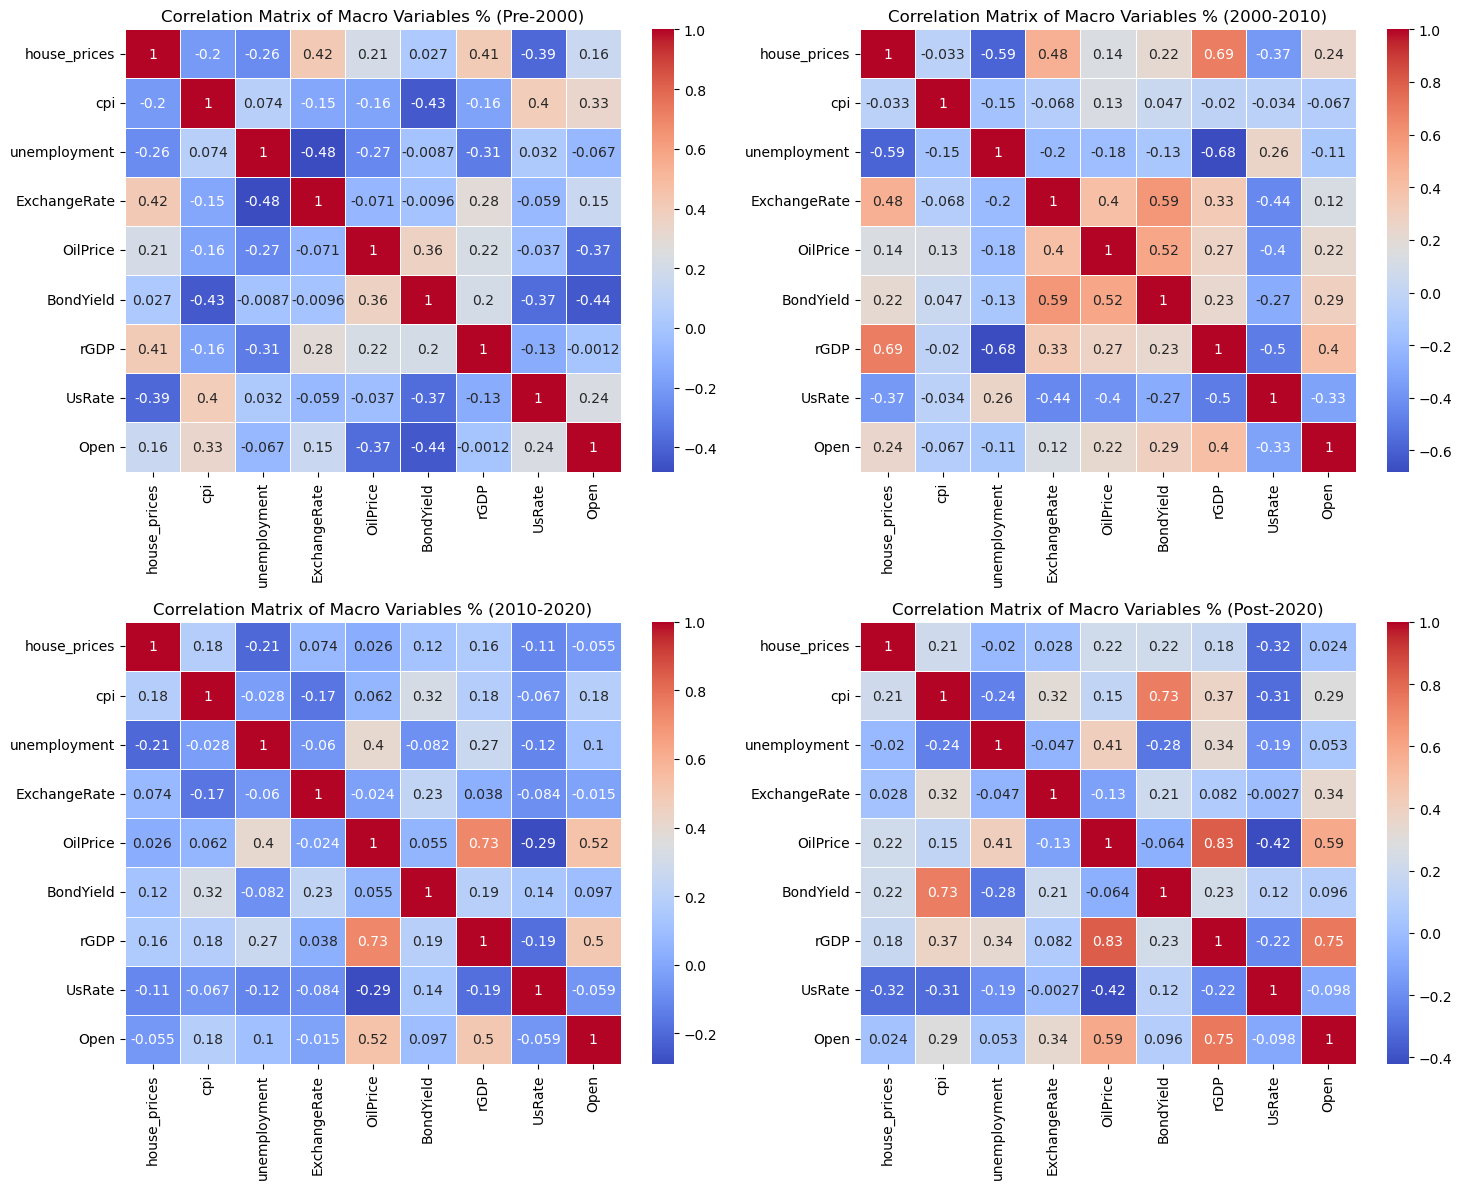

In [37]:
percent_df_pre = percent_df[percent_df.index < '1999-12-01']
percent_df_early = percent_df[(percent_df.index > '1999-12-01') & (percent_df.index < '2009-12-01')]
percent_df_late = percent_df[percent_df.index > '2009-12-01']
percent_df_covid = percent_df[percent_df.index > '2019-12-01']

fig, ax = plt.subplots(2, 2, figsize=(15, 12))
sns.heatmap(percent_df_pre.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[0, 0])
ax[0, 0].set_title('Correlation Matrix of Macro Variables % (Pre-2000)')
sns.heatmap(percent_df_early.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax = ax[0, 1])
ax[0, 1].set_title('Correlation Matrix of Macro Variables % (2000-2010)')
sns.heatmap(percent_df_late.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[1, 0])
ax[1, 0].set_title('Correlation Matrix of Macro Variables % (2010-2020)')
sns.heatmap(percent_df_covid.corr(), annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[1, 1])
ax[1, 1].set_title('Correlation Matrix of Macro Variables % (Post-2020)')
plt.tight_layout()
plt.show()  

# **Modeling**
____

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split, ParameterGrid, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# metrics
from sklearn.metrics import * # accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve as sk_roc_curve
from scipy.stats import entropy

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet


### **Split the Data**

In [47]:
X = df.drop(columns=['UsRate'])
Y = df['UsRate']

tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(X, Y))

train_idx, test_idx = splits[0]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

## **Linear Regression**

In [ ]:
def linearModeling(pipeline, parameterGrid, x_train,x_test, y_train,y_test):
    if pipeline['model'] == 'LinearRegression':
        fitted = pipeline.fit(X_train,y_train)
        pred = fitted.predict(x_test)
        
    else:
        tscv = TimeSeriesSplit(n_splits=5)
        search = GridSearchCV(pipeline, parameterGrid,cv = tscv, n_jobs=-1)
        search.fit(x_train,y_train)
        pred = search.predict(x_test)
    mse = mean_squared_error(y_test,pred)
    print(mse)  



#### **OLS**

In [56]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_params = {}  
lr_model = linearModeling(lr_pipeline, lr_params, X_train, X_test, y_train, y_test)


5.23282761109069


#### **Ridge**

In [57]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
ridge_params = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}
ridge_model = linearModeling(ridge_pipeline, ridge_params, X_train, X_test, y_train, y_test)

0.9504402929631287


#### **Lasso**

In [58]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])
lasso_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}
lasso_model = linearModeling(lasso_pipeline, lasso_params, X_train, X_test, y_train, y_test)

0.24538468598029034


#### **Elastic Net**

In [59]:
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])
elastic_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_model = linearModeling(elastic_pipeline, elastic_params, X_train, X_test, y_train, y_test)


0.26663093565756135
